# Lab for Week 5: Data Visualization


We will walk through the fundamentals of creating insightful plots using three powerful Python libraries.

- **Matplotlib** : The foundational plotting library that almost everything else in the Python visualization is built on top of
- **Seaborn** : Built on Matplotlib, with a simpler syntax designed for statistical plots and working directly with pandas DataFrames
- **Plotly** : Built for creating interactive, web-based visuals

We'll start with Matplotlib to understand the fundamentals of how a plot is built, then move to Seaborn for cleaner statistical plotting, and finish with Plotly to add interactivity.

In [ ]:
#!pip install matplotlib seaborn plotly
#!pip install --upgrade "plotly>=5.24" "narwhals>=1.9"

In [ ]:
## Importing the Libraries

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import pandas as pd
import numpy as np

In [ ]:
print("matplotlib version:", plt.matplotlib.__version__)
print("seaborn version:", sns.__version__)
print("plotly version:", px.__version__ if hasattr(px, '__version__') else "see plotly.__version__")
print("pandas version:", pd.__version__)
print("numpy version:", np.__version__)

## Part 1: Matplotlib

Matplotlib is the original plotting library in Python, and almost every other visualization library (including Seaborn) is built on top of it. Before we plot anything, it helps to understand the basic building blocks Matplotlib uses.

### Anatomy of a Matplotlib plot

- **Figure**: The entire window or page. Think of it as the blank canvas that everything else sits inside.
  
- **Axes**: A single plot within the Figure. A Figure can contain one Axes, or many (e.g. a 2x2 grid of subplots). This is where your actual chart (lines, bars, points) gets drawn.
  
- **Axis**: The individual x or y number line on an Axes, controlling the scale and tick marks.

So the hierarchy is: **Figure → Axes → Axis**. One Figure can hold multiple Axes, and each Axes has its own x-axis and y-axis.

<img src="images/anatomy.png" width="500" height="350">

### One Axes vs. Multiple Axes in a Figure

A single Figure isn't limited to one plot, it can hold as many Axes as you want, arranged in a grid.

**One Axes in a Figure**: Both series plotted on the same set of x/y axes, sharing one plot area.

<img src="images/oneaxe.png" width="500" height="350">

**Two Axes in a Figure**: The same two series, but each given its own separate Axes side by side, useful when the scales or trends are different enough that overlaying them isn't clear.

<img src="images/twoaxes.png" width="500" height="350">

You create multiple Axes using `plt.subplots(nrows, ncols)`, which returns a Figure and a grid of Axes. When you have more than one row and column, the Axes come back as a 2D array that you index like a matrix:

<img src="images/subplots.png" width="500" height="350">

So `axs[0, 0]` is the top-left Axes, `axs[1, 1]` is the bottom-right, and so on. We'll use this indexing later in the lab whenever we want to place multiple charts in one Figure.

### Matplotlib Syntax Reference

Here's a quick reference table for the core pieces of syntax we'll be using throughout this lab. 

| Syntax | What it does |
|---|---|
| `fig` | The Figure object, the entire canvas/window everything is drawn on |
| `ax` | The Axes object, a single plot area within the Figure that holds your actual chart |
| `plt.subplots()` | Creates a Figure and one or more Axes in one line, returned as `fig, ax` |
| `plt.subplots(nrows, ncols)` | Creates a Figure with a grid of Axes (e.g. `nrows=1, ncols=2` for two plots side by side) |
| `ax.plot(x, y)` | Draws a line plot connecting `x` and `y` values |
| `ax.scatter(x, y)` | Draws a scatter plot of individual points |
| `ax.bar(x, height)` | Draws a bar chart |
| `ax.hist(data)` | Draws a histogram showing the distribution of `data` |
| `ax.boxplot(data)` | Draws a boxplot showing the distribution/spread of `data` |
| `ax.pie(values, labels)` | Draws a pie chart |
| `ax.set_title("...")` | Sets the title of that specific Axes |
| `ax.set_xlabel("...")` | Sets the x-axis label |
| `ax.set_ylabel("...")` | Sets the y-axis label |
| `ax.legend()` | Displays a legend, using the `label=` arguments passed to plotting calls |
| `plt.show()` | Renders and displays the Figure |

### Explicit Interface

The explicit interface means you create the `Figure` and `Axes` objects yourself, and then call methods directly on them.

In [ ]:
fig, ax = plt.subplots()          # Explicitly create a Figure and Axes
ax.plot([1, 2, 3], [4, 5, 6])
ax.set_title("Explicit Plot")
plt.show()

- Here, `fig` is the whole canvas, and `ax` is the single Axes we're drawing on. 
  
- Every method call, `.plot()`, `.set_title()`, is called directly on `ax`, so there's no confusion about which Axes it applies to. 
  
- This becomes especially important once we have multiple subplots, since we can address each one individually (`ax1.plot(...)`, `ax2.plot(...)`, etc.).

In [ ]:
fig, axs = plt.subplots(2, 2, figsize=(10, 8))  # 2 rows, 2 columns

axs[0, 0].plot([1, 2, 3], [4, 5, 6])
axs[0, 0].set_title("First Plot showing line chart")

axs[0, 1].bar(["A", "B", "C"], [3, 7, 5])
axs[0, 1].set_title("Second Plot showing bar chart")

axs[1, 0].scatter([1, 2, 3, 4], [10, 15, 13, 18])
axs[1, 0].set_title("Third Plot showing scatter chart")

data = np.random.normal(0, 1, 200)
axs[1, 1].hist(data, bins=15)
axs[1, 1].set_title("Fourth Plot showing histogram")

plt.tight_layout()
plt.show()

### Implicit Interface

The implicit interface uses `plt` directly, without creating `Figure` or `Axes` objects yourself. Matplotlib keeps track of a "current" Figure and Axes behind the scenes.

In [ ]:
plt.plot([1, 2, 3], [4, 5, 6])
plt.title("Implicit Plot")
plt.show()

- Notice there's no `fig` or `ax` here, we just call `plt.plot()` and `plt.title()` directly, and Matplotlib figures out where to draw them. 
  
- This is quicker to type, but it relies on Matplotlib's internal idea of "the current Axes," which can get confusing once you have multiple subplots and lose track of which one is "current."

### Example: Multiple Subplots Using Implicit Interface

In [ ]:
plt.figure(figsize=(10, 8))

plt.subplot(2, 2, 1)  # (nrows, ncols, index)
plt.plot([1, 2, 3], [4, 5, 6])
plt.title("First Plot")

plt.subplot(2, 2, 2)  # switch to the 2nd subplot
plt.bar(["A", "B", "C"], [3, 7, 5])
plt.title("Second Plot")

plt.subplot(2, 2, 3)  # switch to the 3rd subplot
plt.scatter([1, 2, 3, 4], [10, 15, 13, 18])
plt.title("Third Plot")

plt.subplot(2, 2, 4)  # switch to the 4th subplot
data = np.random.normal(0, 1, 200)
plt.hist(data, bins=15)
plt.title("Fourth Plot")

plt.tight_layout()
plt.show()

## Building Our Dataset

To practice each type of chart, we'll use a small synthetic dataset for a coffee chain. We'll build a few related pieces of data:

- **Monthly revenue** for the company as a whole
  
- **Store-level data** (size and revenue)
  
- **Regional revenue totals**
  
- **Daily transaction amounts**
  
- **Revenue by product category** 

In [ ]:
np.random.seed(42)

# Monthly revenue for the company 
monthly_sales_df = pd.DataFrame({
    "month": np.arange(1, 13),
    "revenue": [42000, 43500, 45200, 47000, 49500, 52000,
                54800, 53200, 51000, 55500, 58200, 62000]
})

monthly_sales_df["last_year_revenue"] = [38000, 39500, 40200, 42000, 44500, 46000,
                                          48800, 47200, 46000, 49500, 51200, 54000]
monthly_sales_df.head()

# Store-level data 
store_size = np.random.randint(500, 3000, size=20)
store_df = pd.DataFrame({
    "store_id": np.arange(1, 21),
    "store_size_sqft": store_size,
    "monthly_revenue": store_size * 25 + np.random.normal(0, 3000, size=20)
})

# Regional revenue totals
regional_df = pd.DataFrame({
    "region": ["North", "South", "East", "West"],
    "total_revenue": [185000, 142000, 168000, 121000]
})

# Daily transaction amounts 
transactions_df = pd.DataFrame({
    "transaction_amount": np.random.normal(loc=8.5, scale=3, size=500).clip(min=1)
})

# Revenue by product category 
categories = ["Coffee", "Pastries", "Cold Drinks", "Merchandise"]
category_df = pd.DataFrame({
    "category": (["Coffee"] * 30) + (["Pastries"] * 30) + (["Cold Drinks"] * 30) + (["Merchandise"] * 30),
    "revenue": np.concatenate([
        np.random.normal(1200, 200, 30),
        np.random.normal(700, 150, 30),
        np.random.normal(900, 250, 30),
        np.random.normal(300, 100, 30)
    ])
})

In [ ]:
monthly_sales_df.head()

In [ ]:
store_df.head()

In [ ]:
regional_df

In [ ]:
transactions_df.head()

In [ ]:
category_df.head()

### Line Chart

Line charts are best for showing a trend over a continuous sequence, like revenue over time.

**General syntax:**

```python
fig, ax = plt.subplots()
ax.plot(x, y, marker='o', color='...', label='...') #marker_types: '0', '*', '+', 'D', etc.
ax.set_title("...")
ax.set_xlabel("...")
ax.set_ylabel("...")
ax.legend()
plt.show()
```

Let's assign our `x` and `y` values from `monthly_sales_df` before plotting.

In [ ]:
monthly_sales_df.head()

In [ ]:
x = monthly_sales_df["month"]
y = monthly_sales_df["revenue"]

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(x, y, marker='o', color='blue', label='Total Revenue')
ax.set_title("Monthly Revenue")
ax.set_xlabel("Month")
ax.set_ylabel("Revenue ($)")
ax.legend()
plt.show()

In [ ]:
y_last_year = monthly_sales_df["last_year_revenue"]


In [ ]:

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(x, y, marker='o', color='blue', label='This Year')
ax.plot(x, y_last_year, marker='s', color='black', label='Last Year')
ax.set_title("Monthly Revenue Comparison")
ax.set_xlabel("Month")
ax.set_ylabel("Revenue ($)")
ax.legend()
plt.show()

### Scatter Plot

Scatter plots are best for showing the relationship between two continuous variables.

**General syntax:**

```python
fig, ax = plt.subplots()
ax.scatter(x, y, color='...', s=..., alpha=...) #s: size of each point , alpha: sets transparency
ax.set_title("...")
ax.set_xlabel("...")
ax.set_ylabel("...")
plt.show()
```

In [ ]:
store_df.head()

In [ ]:
x = store_df["store_size_sqft"]
y = store_df["monthly_revenue"]

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(x, y, color='blue', s= 60, alpha = 0.6)
ax.set_title("Store Size vs Monthly Revenue")
ax.set_xlabel("Store Size (sq ft)")
ax.set_ylabel("Monthly Revenue ($)")
plt.show()

### Bar Chart

Bar charts are best for comparing totals across categories.

**General syntax:**

```python
fig, ax = plt.subplots()
ax.bar(x, height, color='...', width=...)
ax.set_title("...")
ax.set_xlabel("...")
ax.set_ylabel("...")
plt.show()
```

In [ ]:
x = regional_df["region"]
y = regional_df["total_revenue"]

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x, y, width=0.6)
ax.set_title("Total Revenue by Region")
ax.set_xlabel("Region")
ax.set_ylabel("Total Revenue ($)")
plt.show()

- `width=0.6` controls how wide each bar is (as a fraction of the space available between categories, default is `0.8`) 
  
- Unlike the line and scatter plots, `x` here is categorical (`region` names) rather than numeric


### Histogram

Histograms are best for showing the distribution of a single continuous variable. here,

**General syntax:**

```python
fig, ax = plt.subplots()
ax.hist(x, bins=..., color='...', edgecolor='...')
ax.set_title("...")
ax.set_xlabel("...")
ax.set_ylabel("...")
plt.show()
```

In [ ]:
x = transactions_df["transaction_amount"]

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(x, bins=20, color='grey', edgecolor='white')
ax.set_title("Distribution of Daily Transaction Amounts")
ax.set_xlabel("Transaction Amount ($)")
ax.set_ylabel("Frequency")
plt.show()

- `bins=20` controls how many bars the range of values gets split into, more bins show finer detail, fewer bins show a smoother overall shape
  
- `edgecolor='white'` draws a thin white border around each bar so adjacent bars are visually distinct
  
- Unlike the other charts so far, a histogram only needs one variable (`data`), it's counting how many values fall into each range, not comparing `x` against `y`


### Boxplot

Boxplots are best for comparing the spread and central tendency of a variable across multiple categories.

Each box shows the median (middle line), the interquartile range (the box itself), and whiskers extending to the typical range of the data; points beyond the whiskers are plotted individually as outliers.

**General syntax:**

```python
fig, ax = plt.subplots()
ax.boxplot(data, tick_labels=[...])
ax.set_title("...")
ax.set_xlabel("...")
ax.set_ylabel("...")
plt.show()
```

In [ ]:
category_df.head()

In [ ]:
data = [category_df[category_df["category"] == cat]["revenue"] for cat in categories]

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.boxplot(data, tick_labels=categories)
ax.set_title("Revenue Distribution by Category")
ax.set_xlabel("Product Category")
ax.set_ylabel("Revenue ($)")
plt.show()

### Combining plots using subplots

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(monthly_sales_df["month"], monthly_sales_df["revenue"], marker='o', color='blue')
ax1.set_title("Monthly Revenue Trend")
ax1.set_xlabel("Month")
ax1.set_ylabel("Revenue ($)")

ax2.bar(regional_df["region"], regional_df["total_revenue"], color='blue', width=0.6)
ax2.set_title("Total Revenue by Region")
ax2.set_xlabel("Region")
ax2.set_ylabel("Total Revenue ($)")

plt.tight_layout()
plt.show()

## Exercise: Matplotlib Practice (5 points)

For this exercise, use the **implicit interface** (`plt.` directly) instead of creating `fig, ax` yourself. 

**Question 1: Line Plot**
Using `monthly_sales_df`, plot the monthly revenue trend using `plt.plot()`. Add a title and axis labels.

In [ ]:
# YOUR CODE HERE
# Hint: plt.plot(x, y), then plt.title(), plt.xlabel(), plt.ylabel(), plt.show()


**Question 2: Bar Chart**
Using `regional_df`, plot total revenue by region using `plt.bar()`. Add a title and axis labels.

In [ ]:
# YOUR CODE HERE
# Hint: plt.bar(x, height)


**Question 3: Histogram**
Using `transactions_df`, plot the distribution of `transaction_amount` using `plt.hist()`, with 15 bins.

In [ ]:
# YOUR CODE HERE
# Hint: plt.hist(data, bins=...)


**Question 4: Boxplot**
Using `category_df`, plot a boxplot comparing `revenue` across all four categories using `plt.boxplot()`. You'll need to build the list of arrays first, the same way we did earlier.

In [ ]:
# YOUR CODE HERE
# Hint: build "data" as a list of Series (one per category), then plt.boxplot(data, tick_labels=categories)


**Question 5: Subplots**
Recreate the revenue trend + regional revenue side-by-side Figure from earlier, but this time using the **implicit interface** with `plt.subplot(nrows, ncols, index)` instead of `ax1`/`ax2`.

In [ ]:
# YOUR CODE HERE
# Hint: plt.subplot(1, 2, 1) -> plot the line chart -> plt.subplot(1, 2, 2) -> plot the bar chart -> plt.show()

## Part 2: Seaborn

Seaborn is built on top of Matplotlib, but designed specifically for statistical plots and for working directly with pandas DataFrames, you pass in column names instead of manually pulling out `x` and `y` arrays.

### Case Study: The `tips` Dataset

In [ ]:
tips = sns.load_dataset("tips")
tips.head()

| Column | Description |
|---|---|
| `total_bill` | The total bill amount ($) |
| `tip` | The tip amount ($) |
| `sex` | Gender of the person paying |
| `smoker` | Whether the party included a smoker |
| `day` | Day of the week |
| `time` | Lunch or Dinner |
| `size` | Number of people in the party |

### Seaborn Syntax Reference

| Syntax | What it does |
|---|---|
| `sns.scatterplot(data=df, x=..., y=..., hue=...)` | Draws a scatter plot, with `hue` optionally coloring points by a categorical column |
| `sns.boxplot(data=df, x=..., y=...)` | Draws a boxplot showing distribution/spread across categories |
| `sns.violinplot(data=df, x=..., y=...)` | Similar to a boxplot, but shows the full shape of the distribution (like a smoothed histogram turned sideways) |
| `sns.histplot(data=df, x=...)` | Draws a histogram |
| `sns.barplot(data=df, x=..., y=...)` | Draws a bar chart, automatically computing the mean of `y` per category (with error bars) |
| `sns.countplot(data=df, x=...)` | Draws a bar chart of how many rows fall into each category |
| `sns.heatmap(data)` | Draws a color-coded grid, most often used for correlation matrices |
| `sns.pairplot(data=df)` | Draws scatter plots for every pair of numeric columns, plus histograms on the diagonal |
| `data=` | Almost every Seaborn function takes the whole DataFrame here, then you just refer to column *names* for `x`, `y`, `hue`, etc. |
| `hue=` | Colors points/bars/boxes by a categorical column, effectively adding a third dimension to the plot |

### Scatterplot with `hue`

Let's look at the relationship between the total bill and the tip amount, and use `hue` to see whether that relationship differs by whether the party included a smoker.

**Syntax:**

```python
ax = sns.scatterplot(data=df, x='...', y='...', hue='...')
ax.set_title("...")
plt.show()
```

In [ ]:
tips.head()

In [ ]:
ax = sns.scatterplot(data=tips, x="total_bill", y="tip", hue="smoker")
ax.set_title("Total Bill vs Tip, by Smoker Status")
plt.show()

- `data=tips`: We pass the whole DataFrame, then refer to columns by name for `x`, `y`, `hue`

- `hue="smoker"`: Colors each point by the `smoker` column, and automatically adds a legend, this is the main advantage over plain Matplotlib, where you'd have to manually filter and plot each group separately


### Boxplot

Now let's compare how tip amounts vary across the days of the week, first with a boxplot, then a violin plot, which shows the same idea but with more detail.

**Syntax:**

```python
ax = sns.boxplot(data=df, x='...', y='...')
ax.set_title("...")
plt.show()
```

In [ ]:
ax = sns.boxplot(data=tips, x="day", y="tip")
ax.set_title("Tip Amount by Day")
plt.show()

### Heatmap

Heatmaps are best for visualizing a grid of values using color, most commonly, a correlation matrix showing how strongly each pair of numeric columns is related.

**Syntax:**

```python
corr = df.corr(numeric_only=True)
ax = sns.heatmap(corr, annot=True, cmap='...')
ax.set_title("...")
plt.show()
```

In [ ]:
corr = tips.corr(numeric_only=True)
corr

In [ ]:
ax = sns.heatmap(corr, annot=True, cmap='coolwarm')
ax.set_title("Correlation Between Numeric Columns")
plt.show()

- `annot=True` prints the actual correlation value inside each cell, on top of the color
  
- `cmap='coolwarm'` sets the color scale, red for stronger/positive values, blue for weaker/lower ones in this palette
  
- The color bar on the right shows how colors map to correlation values


### Pairplot

`pairplot` is one of the most useful EDA tools in Seaborn, it draws a scatter plot for every pair of numeric columns in one grid, with histograms along the diagonal showing each column's individual distribution. This gives you a quick overview of every relationship in the dataset in a single call.

**Expected syntax:**

```python
sns.pairplot(data=df, hue='...')
plt.show()
```

In [ ]:
sns.pairplot(data=tips, hue="time")
plt.show()

- Each diagonal cell shows the distribution of that single column (as a smoothed curve), rather than a scatter plot against itself
  
- `hue="time"` colors every point/curve by whether it was Lunch or Dinner, so we can spot differences in one call without writing separate code for each subset

## Part 3: Plotly

Plotly is designed for **interactive** visuals, you can hover over points to see exact values, zoom in, pan around, and toggle legend items on and off, all without writing any extra code. This makes it especially useful for exploratory work and dashboards.

### Case Study: The `gapminder` Dataset

We'll switch to a dataset built into `plotly.express`, country-level development data spanning several decades.

In [ ]:
gapminder = px.data.gapminder()
gapminder.head()

| Column | Description |
|---|---|
| `country` | Country name |
| `continent` | Continent |
| `year` | Year (1952–2007, in 5-year steps) |
| `lifeExp` | Life expectancy at birth (years) |
| `pop` | Population |
| `gdpPercap` | GDP per capita |
| `iso_alpha` | 3-letter country code (used for map plotting) |
| `iso_num` | Numeric country code |

### Plotly Syntax Reference

| Syntax | What it does |
|---|---|
| `px.scatter(df, x=..., y=..., color=..., size=..., hover_name=...)` | Draws an interactive scatter plot |
| `px.line(df, x=..., y=..., color=...)` | Draws an interactive line chart |
| `px.bar(df, x=..., y=..., color=...)` | Draws an interactive bar chart |
| `px.sunburst(df, path=[...], values=...)` | Draws a hierarchical sunburst chart, nested rings showing part-to-whole relationships across categories |
| `px.choropleth(df, locations=..., color=..., hover_name=..., animation_frame=...)` | Draws a color-coded map, shaded by a numeric column |
| `color=` | Colors points/bars/regions by a column, categorical or numeric |
| `size=` | Scales point size by a numeric column (scatter only) |
| `hover_name=` | Sets what's shown as the bold heading in the hover tooltip |
| `animation_frame=` | Adds a play/slider control that animates the chart across values of a column (e.g. `year`) |
| `fig.show()` | Renders and displays the interactive figure |

### Scatter Plot

Let's look at the relationship between GDP per capita and life expectancy for the year 2007, colored by continent, sized by population.

**Syntax:**

```python
fig = px.scatter(df, x='...', y='...', color='...', size='...', hover_name='...')
fig.show()
```

In [ ]:
gapminder.head()

In [ ]:
gapminder_2007 = gapminder[gapminder["year"] == 2007]

In [ ]:
fig = px.scatter(gapminder_2007, x="gdpPercap", y="lifeExp", color="continent",
                  size="pop", hover_name="country",
                  title="GDP per Capita vs Life Expectancy (2007)")
fig.show()

- `color="continent"` colors each point by continent, with an automatic legend
  
- `size="pop"` scales each point's size by that country's population, so India and China stand out as large circles
  
- `hover_name="country"` sets the bold text shown at the top of the tooltip when you hover over a point


### Sunburst Chart

Sunburst charts show hierarchical part-to-whole relationships, nested rings, where each ring is one level deeper into the hierarchy. Here, we'll show population share by continent, then by country within each continent, for 2007.

**Syntax:**

```python
fig = px.sunburst(df, path=['...', '...'], values='...')
fig.show()
```

In [ ]:
fig = px.sunburst(gapminder_2007, path=["continent", "country"], values="pop",
                   title="Population Share by Continent and Country (2007)")
fig.show()

- `path=["continent", "country"]` defines the hierarchy: the inner ring is `continent`, and the outer ring breaks each continent down further into `country` — the order of the list determines the nesting order, from center outward
  
- `values="pop"` sets what determines each slice's size, bigger population means a bigger wedge
  
- Clicking on any ring in the actual interactive chart zooms into that slice


### Choropleth Map

A choropleth is a map where regions are colored according to a numeric value. We'll also add `animation_frame` to animate it across all 12 years in the dataset, using a slider/play button.

**Syntax:**

```python
fig = px.choropleth(df, locations='...', color='...', hover_name='...',
                     animation_frame='...', color_continuous_scale='...')
fig.show()
```

In [ ]:
gapminder.head()

- `locations="iso_alpha"` tells Plotly which column identifies each region, it needs standardized 3-letter country codes to know where to draw each shape on the map

- `color="lifeExp"` colors each country by its life expectancy value
  
- `animation_frame="year"` adds a play button and slider at the bottom, animating the map through each year in the dataset 
  
- `color_continuous_scale="RdYlGn"` sets the color gradient (red → yellow → green, low to high)
  
- `range_color=[...]` locks the color scale to the full min/max across *all* years, without this, the color scale would rescale itself every frame, making it look like nothing changes year to year even as absolute values improve
  
- `hover_name="country"` shows the country name in bold when you hover

In [ ]:
fig = px.choropleth(gapminder, locations="iso_alpha", color="lifeExp",
                     hover_name="country", animation_frame="year",
                     color_continuous_scale="RdYlGn",
                     range_color=[gapminder["lifeExp"].min(), gapminder["lifeExp"].max()],
                     title="Life Expectancy by Country Over Time")
fig.show()

## Part 4: Visualization in Unsupervised Learning

So far we've visualized data with known labels or categories, but in unsupervised learning, there are no labels to begin with. Visualization becomes even more important here: it's often the main way we can tell *whether* meaningful structure (like clusters) exists in the data at all, and how many groups might be present.

We'll use the **Iris dataset**

In [413]:
#!pip install scikit-learn scipy

In [414]:
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from scipy.cluster.hierarchy import dendrogram, linkage

iris = load_iris()
iris_df = pd.DataFrame(iris.data, columns=iris.feature_names)
iris_df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


### Elbow Method

Before running K-Means, we need to decide how many clusters (`k`) to use. 

We run K-Means for a range of `k` values, and plot each one's **inertia** (a measure of how tightly the points cluster around their centroids, lower is tighter). We look for the "elbow", the point where adding more clusters stops giving a big improvement.

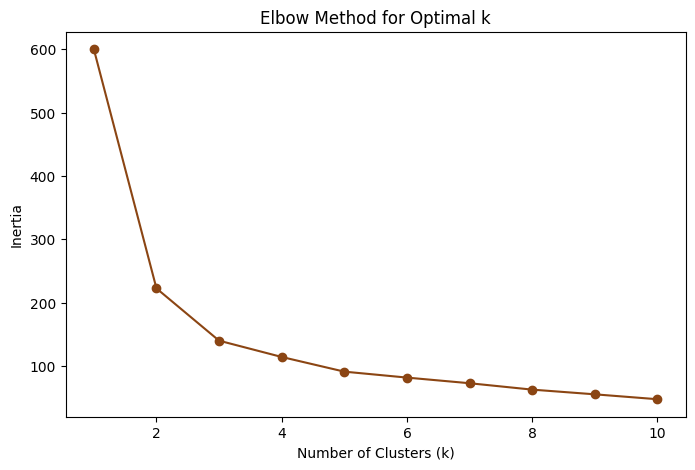

In [415]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(iris_df)

inertias = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(range(1, 11), inertias, marker='o', color='saddlebrown')
ax.set_title("Elbow Method for Optimal k")
ax.set_xlabel("Number of Clusters (k)")
ax.set_ylabel("Inertia")
plt.show()

- `StandardScaler()` rescales all 4 features to have mean 0 and standard deviation 1, before clustering. This is important because K-Means uses distance, and without scaling, features with larger raw ranges would dominate the distance calculation
  
- `n_init=10` runs K-Means 10 times with different random starting centroids and keeps the best result, since K-Means can converge to a suboptimal solution depending on where it starts
  
- `kmeans.inertia_` is the sum of squared distances from each point to its assigned cluster centroid, lower means tighter clusters

The inertia drops sharply from k=1 to k=3, then flattens out, that bend at **k=3** is the "elbow," suggesting 3 clusters is a reasonable choice.

### K-Means Cluster Scatter Plot

Now let's fit K-Means with `k=3` (based on the elbow) and visualize the resulting clusters. Since we have 4 features but can only plot 2 at a time, we'll use petal length and petal width, these tend to separate the groups most clearly.



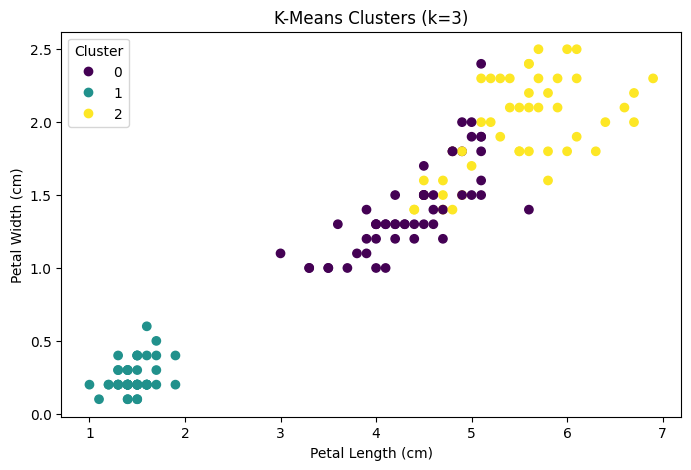

In [416]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
labels = kmeans.fit_predict(X_scaled)

fig, ax = plt.subplots(figsize=(8, 5))
scatter = ax.scatter(iris_df["petal length (cm)"], iris_df["petal width (cm)"], c=labels, cmap='viridis')

ax.set_title("K-Means Clusters (k=3)")
ax.set_xlabel("Petal Length (cm)")
ax.set_ylabel("Petal Width (cm)")
ax.legend(*scatter.legend_elements(), title="Cluster")
plt.show()

- `fit_predict()` fits K-Means and returns each point's assigned cluster label in one step
  
- `c=labels` colors each point by its cluster assignment, note this is `c=`, not `hue=`, since we're using plain Matplotlib here rather than Seaborn
  
- `cmap='viridis'` sets the color palette used to map cluster numbers to colors
  
- `scatter.legend_elements()` automatically builds a legend from the color-to-cluster mapping, which is convenient since we're plotting raw cluster numbers rather than categorical labels

### Dimensionality Reduction: PCA and t-SNE

We only used 2 of the 4 features in the scatter plot above, but there's information in all 4 dimensions. **PCA** and **t-SNE** are two techniques that compress high-dimensional data down to 2D, so we can visualize *all* the features at once, not just a pair of them.

- **PCA (Principal Component Analysis)**: finds the directions of greatest variance in the data and projects onto those, fast, and preserves global structure well.
  
- **t-SNE**: focuses on preserving local neighborhoods (which points are close to which)

/Users/anushkaojha/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:335: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/anushkaojha/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:335: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/anushkaojha/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:335: RuntimeWarning: invalid value encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/anushkaojha/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:336: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/Users/anushkaojha/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:336: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/Users/anushkaojha/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:336: RuntimeWarning: invalid value encountered in matmul

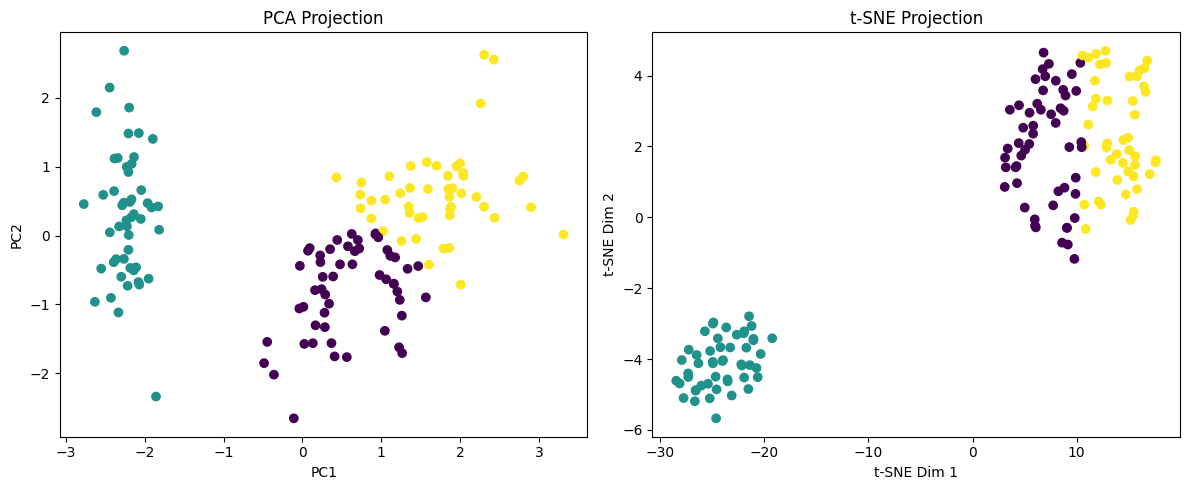

In [417]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X_scaled)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='viridis')
ax1.set_title("PCA Projection")
ax1.set_xlabel("PC1")
ax1.set_ylabel("PC2")

ax2.scatter(X_tsne[:, 0], X_tsne[:, 1], c=labels, cmap='viridis')
ax2.set_title("t-SNE Projection")
ax2.set_xlabel("t-SNE Dim 1")
ax2.set_ylabel("t-SNE Dim 2")

plt.tight_layout()
plt.show()

- `n_components=2` tells both PCA and t-SNE to compress down to 2 dimensions, so we can plot them
  
- `PC1`/`PC2` (Principal Components 1 and 2) aren't original features, they're new axes computed as combinations of the original 4 features, chosen to capture the most variance
  
- `perplexity=30` (t-SNE-specific) roughly controls how many neighbors each point considers when preserving local structure
  
- We colored both plots by the K-Means cluster labels from before, so we can see how the clustering looks once we account for all 4 features rather than just 2